# 01. SECOM Data Understanding

UCI SECOM 원본 데이터의 구조와 품질을 확인한다. 이 단계에서는 전처리, 리샘플링, Feature selection 및 모델링을 수행하지 않는다.

In [1]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError(f'Project root could not be resolved from {cwd}')
MPL_CACHE_DIR = PROJECT_ROOT / '.cache' / 'matplotlib'
MPL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(MPL_CACHE_DIR)
sys.path.insert(0, str(PROJECT_ROOT))

import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from src.load_data import load_secom_dataset, split_secom_data

FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
sns.set_theme(style='whitegrid')
print(f'Project root: {PROJECT_ROOT}')
print(f'Matplotlib cache: {MPL_CACHE_DIR}')

Project root: C:\Projects\semiconductor-secom-yield-analysis
Matplotlib cache: C:\Projects\semiconductor-secom-yield-analysis\.cache\matplotlib


## 1. Load data and inspect official information

프로젝트 로더는 `ucimlrepo.fetch_ucirepo(id=179)`를 사용한다. Target 의미는 추측하지 않고 UCI 공식 설명을 따른다. UCI는 `-1`을 Pass, `1`을 Fail로 설명한다.

In [2]:
dataset = load_secom_dataset()
X, y = split_secom_data(dataset)
X = X.copy()
y = y.copy()
metadata = dataset.metadata
variables = dataset.variables.copy()
metadata_summary = {key: metadata.get(key) for key in [
    'uci_id', 'name', 'repository_url', 'data_url', 'abstract', 'area',
    'tasks', 'characteristics', 'num_instances', 'num_features',
    'feature_types', 'target_col', 'has_missing_values', 'year_created',
    'last_updated', 'dataset_doi', 'creators', 'intro_paper'
] if key in metadata}
display(pd.Series(metadata_summary, name='official_metadata').to_frame())
print(f'ucimlrepo automatic features object: {type(dataset.data.features).__name__}')
print(f'ucimlrepo automatic targets object: {type(dataset.data.targets).__name__}')
print('The package returned the complete original table but no automatic split;')
print('the project loader split the official `class` target without changing values.')
print('Official additional_info:')
display(metadata.get('additional_info'))
print(f'Variables shape: {variables.shape}')
display(variables.head(10))

,official_metadata
uci_id,179
name,SECOM
repository_url,https://archive.ics.uci.edu/dataset/179/secom
data_url,https://archive.ics.uci.edu/static/public/179/...
abstract,Data from a semi-conductor manufacturing process
area,Computer Science
tasks,"[Classification, Causal-Discovery]"
characteristics,[Multivariate]
num_instances,1567
num_features,591


ucimlrepo automatic features object: NoneType
ucimlrepo automatic targets object: NoneType
The package returned the complete original table but no automatic split;
the project loader split the official `class` target without changing values.
Official additional_info:


{'summary': 'A complex modern semi-conductor manufacturing process is normally under consistent surveillance via the monitoring of signals/variables collected from sensors and or process measurement points. However, not all of these signals are equally valuable in a specific monitoring system. The measured signals contain a combination of useful information, irrelevant information as well as noise. It is often the case that useful information is buried in the latter two. Engineers typically have a much larger number of signals than are actually required. If we consider each type of signal as a feature, then feature selection may be applied to identify the most relevant signals. The Process Engineers may then use these signals to determine key factors contributing to yield excursions downstream in the process. This will enable an increase in process throughput, decreased time to learning and reduce the per unit production costs.\r\n\r\nTo enhance current business improvement techniques 

Variables shape: (0, 0)


""


## 2. Shapes, dtypes, target distribution, and class imbalance

Total samples: 1,567
Feature count: 591
X shape: (1567, 591); y shape: (1567, 1)
Target column: class
Target unique values: [-1, 1]


,feature_count
dtype,
float64,590
str,1


,dtype
timestamp,str
Attribute 1,float64
Attribute 2,float64
Attribute 3,float64
Attribute 4,float64
...,...
Attribute 586,float64
Attribute 587,float64
Attribute 588,float64
Attribute 589,float64


,count,ratio,percent
class,,,
-1,1463,0.933631,93.363114
1,104,0.066369,6.636886


Majority/minority imbalance ratio: 14.067:1


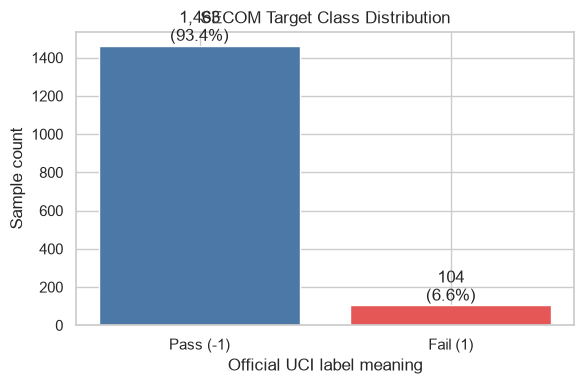

Saved: C:\Projects\semiconductor-secom-yield-analysis\reports\figures\target_class_distribution.png


In [3]:
target_col = y.columns[0]
target = y[target_col]
feature_dtypes = X.dtypes.astype(str).rename('dtype').to_frame()
dtype_counts = feature_dtypes['dtype'].value_counts().rename_axis('dtype').to_frame('feature_count')
class_counts = target.value_counts(dropna=False).sort_index()
class_distribution = pd.DataFrame({
    'count': class_counts,
    'ratio': class_counts / len(target),
    'percent': class_counts / len(target) * 100,
})
imbalance_ratio = int(class_counts.max()) / int(class_counts.min())
print(f'Total samples: {len(X):,}')
print(f'Feature count: {X.shape[1]:,}')
print(f'X shape: {X.shape}; y shape: {y.shape}')
print(f'Target column: {target_col}')
print(f'Target unique values: {sorted(target.dropna().unique().tolist())}')
display(dtype_counts)
display(feature_dtypes)
display(class_distribution)
print(f'Majority/minority imbalance ratio: {imbalance_ratio:.3f}:1')

fig, ax = plt.subplots(figsize=(6, 4))
labels = class_counts.index.to_series().map({-1: 'Pass (-1)', 1: 'Fail (1)'}).tolist()
ax.bar(labels, class_counts.values, color=['#4C78A8', '#E45756'])
ax.set(ylabel='Sample count', xlabel='Official UCI label meaning')
ax.set_title('SECOM Target Class Distribution', pad=16)
ax.margins(y=0.16)
for i, value in enumerate(class_counts.values):
    ax.annotate(f'{value:,}\n({value / len(target):.1%})', (i, value), xytext=(0, 6), textcoords='offset points', ha='center', va='bottom')
fig.tight_layout()
target_figure = FIGURES_DIR / 'target_class_distribution.png'
fig.savefig(target_figure, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {target_figure}')

## 3. Missing values

결측치를 수정하지 않고 원본 상태로 집계한다.

Total missing cells: 41,951 / 926,097
Overall missing ratio: 0.045299 (4.53%)
Features without missing values: 53
Top 20 features by missing count:


,missing_count,missing_ratio,missing_percent
Attribute 158,1429,0.911934,91.193363
Attribute 159,1429,0.911934,91.193363
Attribute 293,1429,0.911934,91.193363
Attribute 294,1429,0.911934,91.193363
Attribute 86,1341,0.855775,85.577537
Attribute 221,1341,0.855775,85.577537
Attribute 359,1341,0.855775,85.577537
Attribute 493,1341,0.855775,85.577537
Attribute 110,1018,0.649649,64.964901
Attribute 111,1018,0.649649,64.964901


All feature-level missing statistics:


,missing_count,missing_ratio,missing_percent
Attribute 158,1429,0.911934,91.193363
Attribute 159,1429,0.911934,91.193363
Attribute 293,1429,0.911934,91.193363
Attribute 294,1429,0.911934,91.193363
Attribute 86,1341,0.855775,85.577537
...,...,...,...
Attribute 574,0,0.000000,0.000000
Attribute 575,0,0.000000,0.000000
Attribute 576,0,0.000000,0.000000
Attribute 577,0,0.000000,0.000000


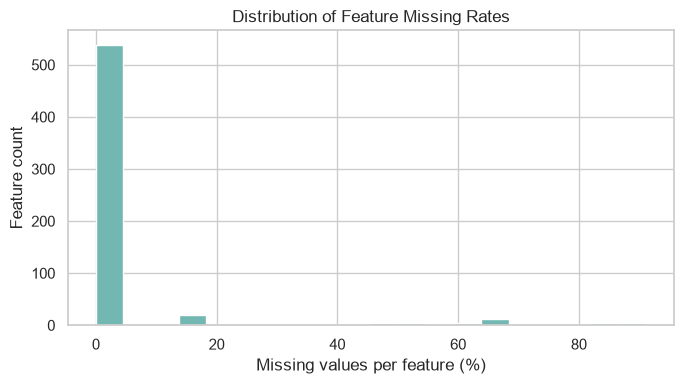

Saved: C:\Projects\semiconductor-secom-yield-analysis\reports\figures\feature_missing_rate_distribution.png


In [4]:
missing_count = X.isna().sum()
missing_rate = X.isna().mean()
missing_by_feature = pd.DataFrame({
    'missing_count': missing_count,
    'missing_ratio': missing_rate,
    'missing_percent': missing_rate * 100,
}).sort_values(['missing_count', 'missing_percent'], ascending=False)
total_missing = int(missing_count.sum())
total_cells = int(X.shape[0] * X.shape[1])
overall_missing_ratio = total_missing / total_cells
features_without_missing = int((missing_count == 0).sum())
print(f'Total missing cells: {total_missing:,} / {total_cells:,}')
print(f'Overall missing ratio: {overall_missing_ratio:.6f} ({overall_missing_ratio:.2%})')
print(f'Features without missing values: {features_without_missing:,}')
print('Top 20 features by missing count:')
display(missing_by_feature.head(20))
print('All feature-level missing statistics:')
display(missing_by_feature)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(missing_rate * 100, bins=20, color='#72B7B2', edgecolor='white')
ax.set(title='Distribution of Feature Missing Rates', xlabel='Missing values per feature (%)', ylabel='Feature count')
fig.tight_layout()
missing_figure = FIGURES_DIR / 'feature_missing_rate_distribution.png'
fig.savefig(missing_figure, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {missing_figure}')

## 4. Constant features, duplicate rows, and identical columns

Constant feature는 결측치를 제외한 관측값의 고유값 수가 1 이하인 열로 정의한다. 동일 column은 값과 결측치 위치가 모두 같을 때만 인정한다.

In [5]:
observed_nunique = X.nunique(dropna=True)
constant_features = observed_nunique[observed_nunique <= 1].index.tolist()
all_missing_features = X.columns[X.isna().all()].tolist()
duplicate_row_count = int(X.duplicated(keep='first').sum())
hash_buckets = {}
for column in X.columns:
    hashed = pd.util.hash_pandas_object(X[column], index=False).values.tobytes()
    hash_buckets.setdefault(hashlib.sha256(hashed).hexdigest(), []).append(column)
identical_column_groups = []
for candidates in hash_buckets.values():
    remaining = list(candidates)
    while remaining:
        base = remaining.pop(0)
        group = [base]
        for candidate in remaining.copy():
            if X[base].equals(X[candidate]):
                group.append(candidate)
                remaining.remove(candidate)
        if len(group) > 1:
            identical_column_groups.append(group)
print(f'Constant feature count: {len(constant_features):,}')
print(f'Constant features: {constant_features}')
print(f'All-missing feature count: {len(all_missing_features):,}')
print(f'All-missing features: {all_missing_features}')
print(f'Duplicate feature rows: {duplicate_row_count:,}')
print(f'Identical feature-column group count: {len(identical_column_groups):,}')
print(f'Identical feature-column groups: {identical_column_groups}')

Constant feature count: 116
Constant features: ['Attribute 6', 'Attribute 14', 'Attribute 43', 'Attribute 50', 'Attribute 53', 'Attribute 70', 'Attribute 98', 'Attribute 142', 'Attribute 150', 'Attribute 179', 'Attribute 180', 'Attribute 187', 'Attribute 190', 'Attribute 191', 'Attribute 192', 'Attribute 193', 'Attribute 194', 'Attribute 195', 'Attribute 227', 'Attribute 230', 'Attribute 231', 'Attribute 232', 'Attribute 233', 'Attribute 234', 'Attribute 235', 'Attribute 236', 'Attribute 237', 'Attribute 238', 'Attribute 241', 'Attribute 242', 'Attribute 243', 'Attribute 244', 'Attribute 257', 'Attribute 258', 'Attribute 259', 'Attribute 260', 'Attribute 261', 'Attribute 262', 'Attribute 263', 'Attribute 264', 'Attribute 265', 'Attribute 266', 'Attribute 267', 'Attribute 277', 'Attribute 285', 'Attribute 314', 'Attribute 315', 'Attribute 316', 'Attribute 323', 'Attribute 326', 'Attribute 327', 'Attribute 328', 'Attribute 329', 'Attribute 330', 'Attribute 331', 'Attribute 365', 'Attribu

## 5. Basic descriptive statistics

결측치 처리 전 원본 Feature의 기술통계다.

In [6]:
feature_statistics = X.describe(include='all').T
target_statistics = target.describe()
display(feature_statistics)
display(target_statistics.to_frame(name=target_col))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,1567,1534,15/10/2008 01:52:00,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attribute 1,1561.0,NaN,NaN,NaN,3014.452896,73.621787,2743.24,2966.26,3011.49,3056.65,3356.35
Attribute 2,1560.0,NaN,NaN,NaN,2495.850231,80.407705,2158.75,2452.2475,2499.405,2538.8225,2846.44
Attribute 3,1553.0,NaN,NaN,NaN,2200.547318,29.513152,2060.66,2181.0444,2201.0667,2218.0555,2315.2667
Attribute 4,1553.0,NaN,NaN,NaN,1396.376627,441.69164,0.0,1081.8758,1285.2144,1591.2235,3715.0417
...,...,...,...,...,...,...,...,...,...,...,...
Attribute 586,1566.0,NaN,NaN,NaN,3.067826,3.578033,1.1975,2.3065,2.75765,3.295175,99.3032
Attribute 587,1566.0,NaN,NaN,NaN,0.021458,0.012358,-0.0169,0.013425,0.0205,0.0276,0.1028
Attribute 588,1566.0,NaN,NaN,NaN,0.016475,0.008808,0.0032,0.0106,0.0148,0.0203,0.0799
Attribute 589,1566.0,NaN,NaN,NaN,0.005283,0.002867,0.001,0.0033,0.0046,0.0064,0.0286


,class
count,1567.000000
mean,-0.867262
std,0.498010
min,-1.000000
25%,-1.000000
50%,-1.000000
75%,-1.000000
max,1.000000


## 6. Reproducible summary

In [7]:
summary = {
    'samples': int(X.shape[0]), 'features': int(X.shape[1]),
    'target_column': target_col, 'x_shape': list(X.shape), 'y_shape': list(y.shape),
    'feature_dtype_counts': {str(k): int(v) for k, v in X.dtypes.astype(str).value_counts().items()},
    'target_unique_values': [int(v) for v in sorted(target.dropna().unique())],
    'class_counts': {str(k): int(v) for k, v in class_counts.items()},
    'class_ratios': {str(k): float(v / len(target)) for k, v in class_counts.items()},
    'imbalance_ratio_majority_to_minority': float(imbalance_ratio),
    'total_missing': total_missing, 'total_cells': total_cells,
    'overall_missing_ratio': float(overall_missing_ratio),
    'features_without_missing': features_without_missing,
    'constant_feature_count': len(constant_features), 'constant_features': constant_features,
    'all_missing_feature_count': len(all_missing_features),
    'duplicate_rows': duplicate_row_count,
    'identical_column_group_count': len(identical_column_groups),
    'identical_column_groups': identical_column_groups,
    'top_20_missing_features': missing_by_feature.head(20).reset_index(names='feature').to_dict(orient='records'),
}
print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "samples": 1567,
  "features": 591,
  "target_column": "class",
  "x_shape": [
    1567,
    591
  ],
  "y_shape": [
    1567,
    1
  ],
  "feature_dtype_counts": {
    "float64": 590,
    "str": 1
  },
  "target_unique_values": [
    -1,
    1
  ],
  "class_counts": {
    "-1": 1463,
    "1": 104
  },
  "class_ratios": {
    "-1": 0.9336311423101468,
    "1": 0.06636885768985322
  },
  "imbalance_ratio_majority_to_minority": 14.067307692307692,
  "total_missing": 41951,
  "total_cells": 926097,
  "overall_missing_ratio": 0.04529871061022765,
  "features_without_missing": 53,
  "constant_feature_count": 116,
  "constant_features": [
    "Attribute 6",
    "Attribute 14",
    "Attribute 43",
    "Attribute 50",
    "Attribute 53",
    "Attribute 70",
    "Attribute 98",
    "Attribute 142",
    "Attribute 150",
    "Attribute 179",
    "Attribute 180",
    "Attribute 187",
    "Attribute 190",
    "Attribute 191",
    "Attribute 192",
    "Attribute 193",
    "Attribute 194",
    "

## Scope boundary

이 단계에서는 데이터 품질만 확인했다. 결측치 처리, 클래스 불균형 처리, Feature selection, PCA, 모델 학습 및 설명가능성 분석은 후속 단계에서 수행한다.